# 05 — Modelos finales y comparación integrada

Síntesis del pipeline completo: clasificadores baseline, ensemble ordinal (notebook 04), tuning, diseño 2+3 y diagnóstico OOF (`report-oof`).

**Prerrequisitos:** ejecutar el flujo CLI (idealmente tras el notebook 04):
```
python -m src.main train
python -m src.main train-ensemble
python -m src.main tune
python -m src.main design
python -m src.main fit-final
python -m src.main report-oof
```
`fit-final` entrena el modelo de produccion. `report-oof` genera figuras honestas (OOF 10-fold) para el informe.


In [9]:
%run init_notebook.py


Project root: C:\Users\Usuario\code\miia\proyecto_1_innovacion_tecnologica
Train data:   C:\Users\Usuario\code\miia\proyecto_1_innovacion_tecnologica\data\raw\train.csv


In [10]:
import json
from IPython.display import Image, display

# PROJECT_ROOT, RESULTS_DIR, FIGURES_DIR vienen de %run init_notebook.py
print(f"Results dir: {RESULTS_DIR}")
print(f"Figures dir: {FIGURES_DIR}")

Results dir: C:\Users\Usuario\code\miia\proyecto_1_innovacion_tecnologica\experiments\results
Figures dir: C:\Users\Usuario\code\miia\proyecto_1_innovacion_tecnologica\experiments\results\figures


## Comparación de todos los modelos (holdout y CV)

In [11]:
holdout = pd.read_csv(RESULTS_DIR / "all_models_holdout.csv")
cv = pd.read_csv(RESULTS_DIR / "all_models_cv.csv")

ensemble_models = {
    "lgbm_regressor",
    "xgb_regressor",
    "extratrees_regressor",
    "regression_vote",
}

print("=== Todos los modelos (holdout, por QWK) ===")
display(holdout.sort_values("qwk", ascending=False))

print("=== CV (por QWK medio) ===")
display(cv.sort_values("qwk_mean", ascending=False))

if holdout["model"].isin(ensemble_models).any():
    print("=== Solo ensemble ordinal (holdout) ===")
    display(holdout[holdout["model"].isin(ensemble_models)].sort_values("qwk", ascending=False))


=== Todos los modelos (holdout, por QWK) ===


,model,level,f1_macro,balanced_accuracy,qwk,accuracy
13,lgbm_regressor,advanced,0.385591,0.389112,0.426353,0.600365
3,random_forest,intermediate,0.444126,0.443815,0.415845,0.574818
12,regression_vote,advanced,0.359862,0.368243,0.388604,0.613139
6,svm,intermediate,0.363364,0.407420,0.386736,0.509124
5,ridge_ordinal,basic,0.307032,0.349459,0.381255,0.565693
10,xgb_regressor,advanced,0.357004,0.368773,0.380877,0.591241
1,logistic_regression,basic,0.357811,0.463175,0.379998,0.509124
7,lightgbm,advanced,0.406933,0.395844,0.365343,0.589416
8,xgboost,advanced,0.397662,0.374997,0.360939,0.607664
4,knn,basic,0.323971,0.325032,0.296258,0.607664


=== CV (por QWK medio) ===


,model,level,qwk_mean,qwk_std,f1_macro_mean,f1_macro_std,balanced_accuracy_mean,balanced_accuracy_std
13,lgbm_regressor,advanced,0.413265,0.046993,0.357800,0.040897,0.358158,0.033372
10,xgb_regressor,advanced,0.399136,0.045243,0.380477,0.059048,0.372593,0.043948
6,svm,intermediate,0.393716,0.053510,0.382022,0.031418,0.428398,0.054426
3,random_forest,intermediate,0.393486,0.072483,0.352136,0.023058,0.358291,0.027348
12,regression_vote,advanced,0.382475,0.000000,0.324915,0.000000,0.330619,0.000000
1,logistic_regression,basic,0.374897,0.065684,0.381983,0.035144,0.485078,0.082347
11,extratrees_regressor,advanced,0.368374,0.044396,0.331841,0.027648,0.334731,0.022204
5,ridge_ordinal,basic,0.367433,0.062526,0.301692,0.022965,0.339094,0.019907
7,lightgbm,advanced,0.356524,0.061122,0.324212,0.022664,0.325196,0.020297
8,xgboost,advanced,0.332067,0.056624,0.324771,0.020933,0.325658,0.017972


=== Solo ensemble ordinal (holdout) ===


,model,level,f1_macro,balanced_accuracy,qwk,accuracy
13,lgbm_regressor,advanced,0.385591,0.389112,0.426353,0.600365
12,regression_vote,advanced,0.359862,0.368243,0.388604,0.613139
10,xgb_regressor,advanced,0.357004,0.368773,0.380877,0.591241
11,extratrees_regressor,advanced,0.298183,0.309793,0.282292,0.598540


Baseline (train)


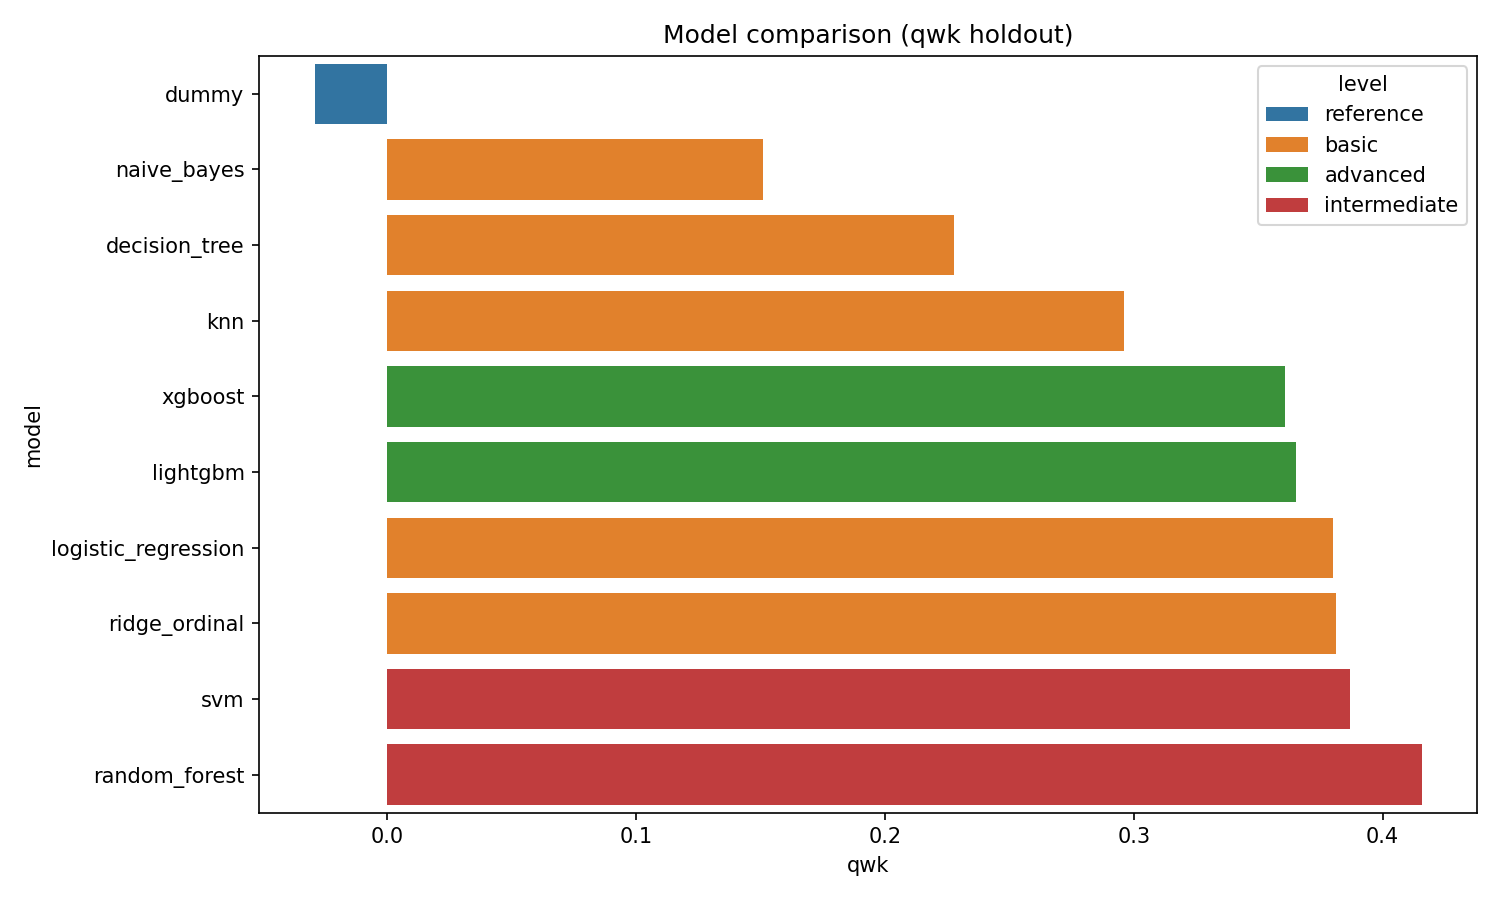

Todos los modelos


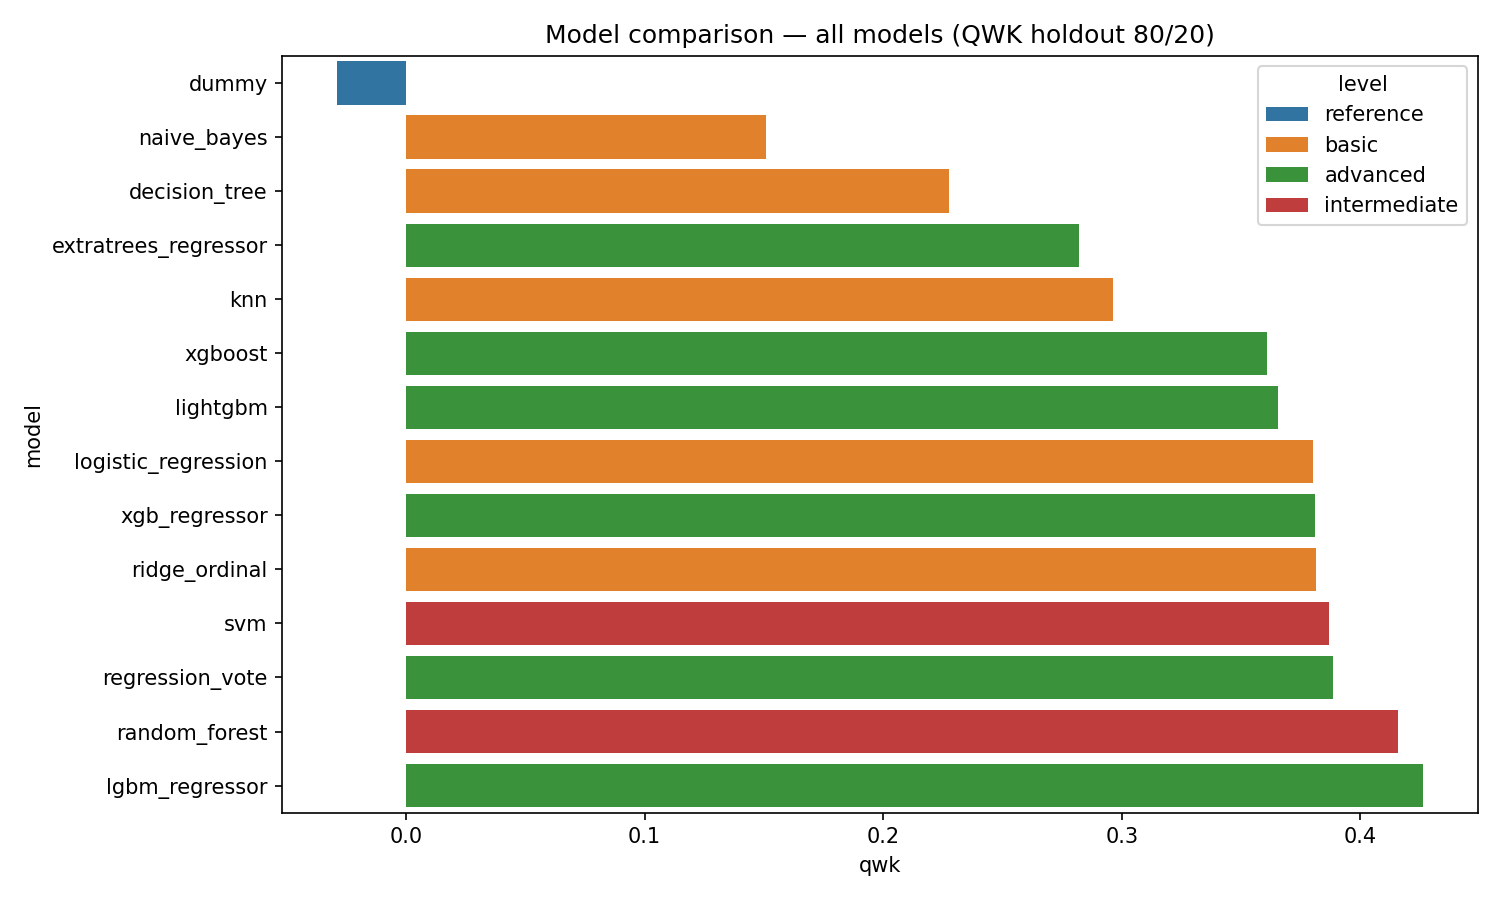

In [12]:
for label, name in [
    ("Baseline (train)", "model_comparison_qwk.png"),
    ("Todos los modelos", "model_comparison_qwk_all.png"),
]:
    p = FIGURES_DIR / name
    if p.exists():
        print(label)
        display(Image(filename=str(p)))

## Tuning del mejor candidato

In [13]:
params_path = RESULTS_DIR / "tuning_best_params.json"
if params_path.exists():
    with open(params_path, encoding="utf-8") as f:
        tuning = json.load(f)
    print(json.dumps(tuning, indent=2))

{
  "model": "lgbm_regressor",
  "best_params": {
    "model__regressor__learning_rate": 0.031430022688291114,
    "model__regressor__min_child_samples": 7,
    "model__regressor__n_estimators": 249,
    "model__regressor__num_leaves": 17
  },
  "best_qwk_cv": 0.42231751760080904
}


## Experimento de diseño: 4 clases vs fusión 2+3

In [14]:
design_path = RESULTS_DIR / "design_merge_classes_23.csv"
if design_path.exists():
    design = pd.read_csv(design_path)
    display(design)

,variant,model,f1_macro,balanced_accuracy,qwk,accuracy
0,four_classes,lgbm_regressor,0.363416,0.366861,0.425768,0.572993
1,merge_classes_23,lgbm_regressor,0.496372,0.499459,0.410541,0.572993


## Modelo final y diagnóstico OOF (honesto)

`fit-final` entrena con todo el train. `report-oof` genera predicciones **out-of-fold** (mismo pipeline e hiperparámetros) para matriz de confusión y métricas por clase sin fuga.

**QWK tabla (comparación de modelos):** `all_models_cv.csv`.  
**QWK y figuras honestas del pipeline final:** `oof_report_summary.json`, `confusion_matrix_oof.png`, `per_class_metrics_oof.csv`, `permutation_importance_oof.png`.

No usar archivos legacy de `evaluate` (`confusion_matrix_final`, `permutation_importance_final`, etc.).

In [15]:
from pathlib import Path

CHECKPOINTS_DIR = PROJECT_ROOT / "experiments" / "checkpoints"
meta_path = RESULTS_DIR / "final_model_meta.json"

if meta_path.exists():
    with open(meta_path, encoding="utf-8") as f:
        meta = json.load(f)
    print(json.dumps(meta, indent=2))

    model = meta.get("model")
    if model:
        cv_df = pd.read_csv(RESULTS_DIR / "all_models_cv.csv")
        holdout_df = pd.read_csv(RESULTS_DIR / "all_models_holdout.csv")
        cv_row = cv_df[cv_df["model"] == model].iloc[0]
        holdout_row = holdout_df[holdout_df["model"] == model].iloc[0]
        print(
            f"\nQWK informe (CV 10-fold): {cv_row['qwk_mean']:.4f} +/- {cv_row['qwk_std']:.4f}"
        )
        print(f"QWK holdout 80/20 (train-ensemble): {holdout_row['qwk']:.4f}")

    oof_path = RESULTS_DIR / "oof_report_summary.json"
    if oof_path.exists():
        with open(oof_path, encoding="utf-8") as f:
            oof_meta = json.load(f)
        print(f"QWK OOF agregado (report-oof): {oof_meta['oof_qwk']:.4f}")

    ckpt = CHECKPOINTS_DIR / "final_model.joblib"
    if ckpt.exists():
        print(f"\nCheckpoint listo: {ckpt}")
else:
    print("Ejecuta: python -m src.main fit-final")

{
  "model": "lgbm_regressor",
  "best_params": {
    "model__regressor__learning_rate": 0.031430022688291114,
    "model__regressor__min_child_samples": 7,
    "model__regressor__n_estimators": 249,
    "model__regressor__num_leaves": 17
  },
  "merged_classes_23": false,
  "fit_on_full_train": true,
  "feature_selection": true,
  "thresholds": [
    0.9711177626411477,
    1.5173510916816946,
    2.15641662119112
  ]
}

QWK informe (CV 10-fold): 0.4133 +/- 0.0470
QWK holdout 80/20 (train-ensemble): 0.4264
QWK OOF agregado (report-oof): 0.4333

Checkpoint listo: C:\Users\Usuario\code\miia\proyecto_1_innovacion_tecnologica\experiments\checkpoints\final_model.joblib


{
  "model": "lgbm_regressor",
  "cv_folds": 10,
  "merged_classes_23": false,
  "feature_selection": true,
  "oof_qwk": 0.4333155923980877,
  "oof_f1_macro": 0.39464803626797695,
  "oof_balanced_accuracy": 0.38305079130667025,
  "limitations": {
    "minority_class": 3,
    "minority_support_oof": 34,
    "minority_recall_oof": 0.08823529411764706,
    "minority_f1_oof": 0.13636363636363635,
    "lowest_recall_class": 3,
    "lowest_recall_oof": 0.08823529411764706,
    "per_class_oof": [
      {
        "class": 0,
        "precision": 0.7263990955342001,
        "recall": 0.8061480552070264,
        "f1": 0.7641986321736545,
        "support": 1594
      },
      {
        "class": 1,
        "precision": 0.3826955074875208,
        "recall": 0.3150684931506849,
        "f1": 0.3456048084147258,
        "support": 730
      },
      {
        "class": 2,
        "precision": 0.34269662921348315,
        "recall": 0.32275132275132273,
        "f1": 0.33242506811989103,
        "suppo

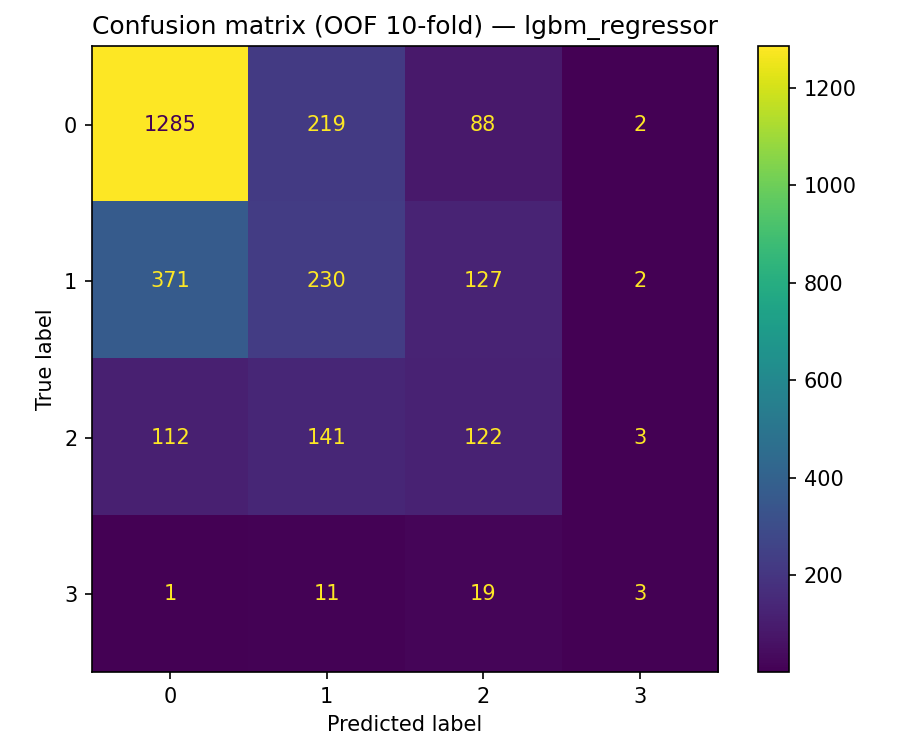

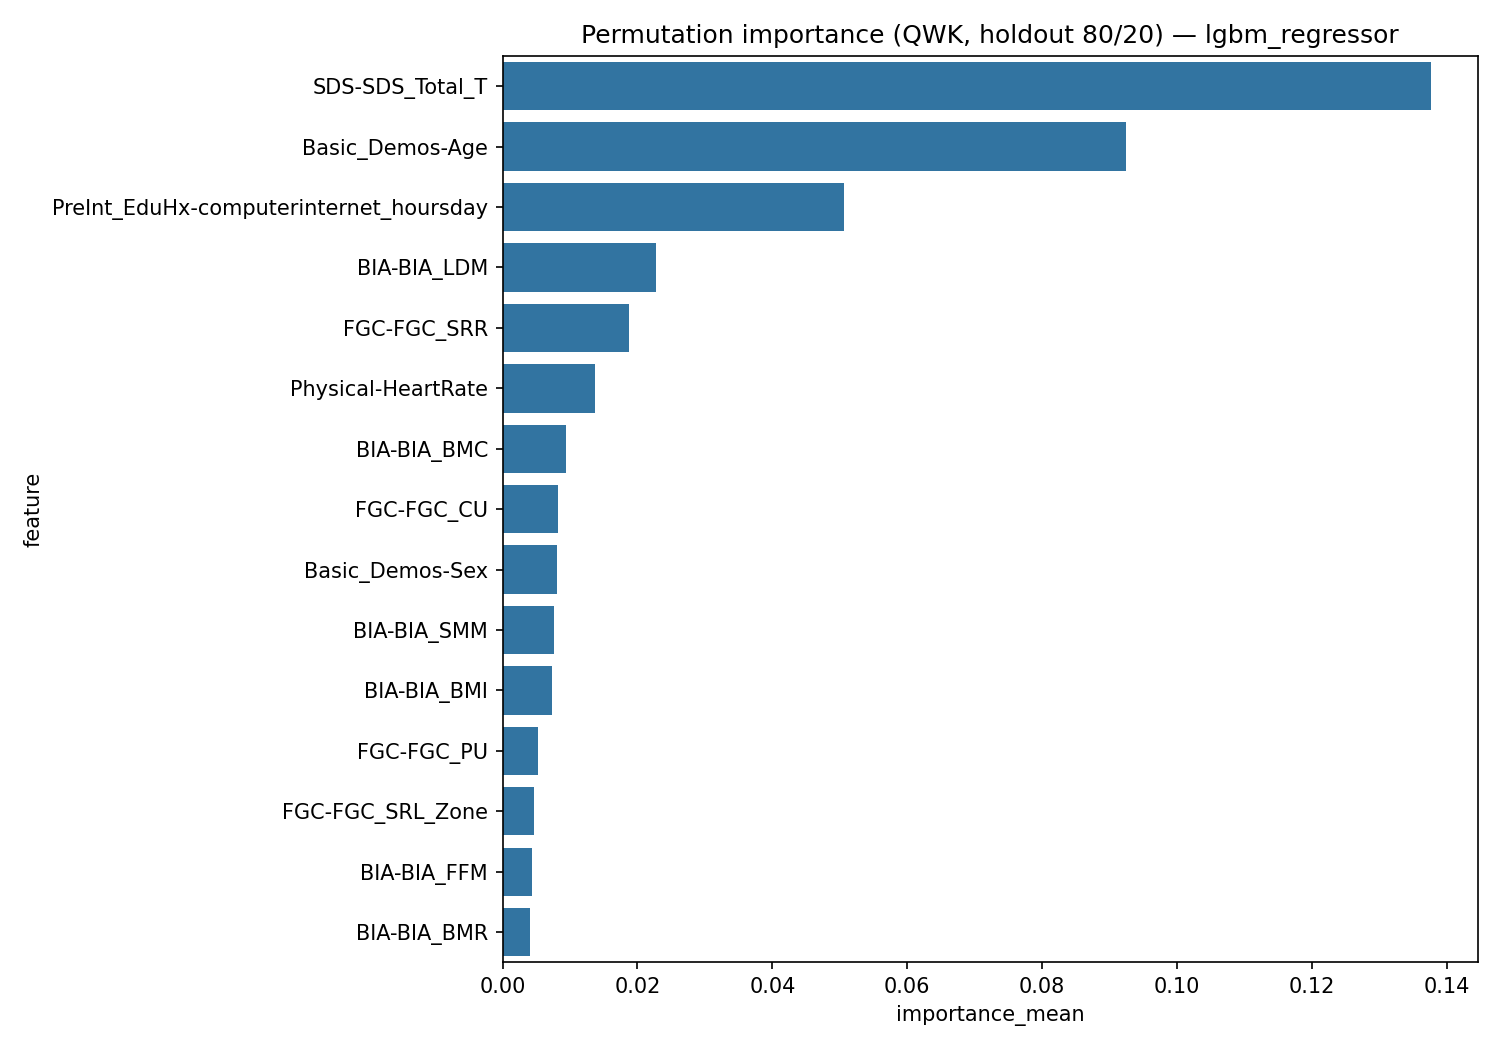

,class,precision,recall,f1,support
0,0,0.726399,0.806148,0.764199,1594
1,1,0.382696,0.315068,0.345605,730
2,2,0.342697,0.322751,0.332425,378
3,3,0.300000,0.088235,0.136364,34


In [16]:
oof_summary = RESULTS_DIR / "oof_report_summary.json"
if oof_summary.exists():
    with open(oof_summary, encoding="utf-8") as f:
        oof = json.load(f)
    print(json.dumps(oof, indent=2))

for name in ["confusion_matrix_oof.png", "permutation_importance_oof.png"]:
    p = FIGURES_DIR / name
    if p.exists():
        display(Image(filename=str(p)))

per_class_oof = RESULTS_DIR / "per_class_metrics_oof.csv"
if per_class_oof.exists():
    display(pd.read_csv(per_class_oof))
else:
    print("Ejecuta: python -m src.main report-oof")